# Regla de Sturges - Base Resumen

## Preparación

In [1]:
#Importamos las librerias pandas, numpy y matplotlib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Resumen = pd.read_csv('Resumen_Limpia.csv', encoding='utf-8-sig')

In [3]:
# Ajustar maximo de filas
pd.options.display.max_rows = None

In [4]:
#Corroboramos valores nulos
valores_nulos = Resumen.isnull().sum()
valores_nulos

Año                              0
Mes                              0
Leads                            0
Efectivos                        0
Ventas Reportadas                0
Obj Ventas                       0
Ventas Real                      0
% CAL                            0
Obj Conversion                   0
Conversion                       0
% CAL.1                          0
Obj UN                          23
UN                              24
%  CAL                           0
Obj SDC                          0
SDC                              0
%  CAL.1                         0
Autorizadas                      0
Formalizado                      0
Contado                          0
Credito                          0
% Autorizadas                    0
% Formalizadas                   0
Obj PDM                          0
PDM                              0
%  CAL.2                         0
% / Conversion Venta- PDM        0
Variacion                        1
Lead / Venta        

## Regla de Sturges: Autorizadas

In [5]:
#Calculamos el numero total de la población "n"
Resumen['Autorizadas'].info()
n = Resumen['Autorizadas'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Autorizadas
Non-Null Count  Dtype
--------------  -----
30 non-null     int64
dtypes: int64(1)
memory usage: 372.0 bytes


np.int64(30)

In [6]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Resumen['Autorizadas'].max()
Min = Resumen['Autorizadas'].min()
Limites = [Min, Max]
Limites

[np.int64(2), np.int64(51)]

In [7]:
#Calculamos el rango R
R = Max - Min
R

np.int64(49)

In [8]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [9]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(8.299398158970655)

**Creación de Categorías a partir de clases**

In [10]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([ 1. ,  9.5, 18. , 26.5, 35. , 43.5, 52. ])

In [11]:
#Nombramos las categorías según su nivel (de mas bajo a mas alto), en vez de un numero generico,
#para que el nombre tenga sentido con lo que se esta midiendo
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (1.0-9.5)',
 'Bajo (9.5-18.0)',
 'Medio bajo (18.0-26.5)',
 'Medio alto (26.5-35.0)',
 'Alto (35.0-43.5)',
 'Muy alto (43.5-52.0)']

In [12]:
#Finalmente creamos las categorías en la columna numérica
Resumen['Autorizadas'] = pd.cut(x=Resumen['Autorizadas'], bins=intervalos, labels=categorias)
Resumen['Autorizadas']

0         Muy bajo (1.0-9.5)
1         Muy bajo (1.0-9.5)
2            Bajo (9.5-18.0)
3         Muy bajo (1.0-9.5)
4            Bajo (9.5-18.0)
5     Medio alto (26.5-35.0)
6     Medio bajo (18.0-26.5)
7     Medio bajo (18.0-26.5)
8     Medio alto (26.5-35.0)
9     Medio bajo (18.0-26.5)
10          Alto (35.0-43.5)
11    Medio alto (26.5-35.0)
12    Medio alto (26.5-35.0)
13    Medio alto (26.5-35.0)
14    Medio alto (26.5-35.0)
15          Alto (35.0-43.5)
16      Muy alto (43.5-52.0)
17          Alto (35.0-43.5)
18    Medio alto (26.5-35.0)
19          Alto (35.0-43.5)
20      Muy alto (43.5-52.0)
21      Muy alto (43.5-52.0)
22    Medio alto (26.5-35.0)
23          Alto (35.0-43.5)
24          Alto (35.0-43.5)
25          Alto (35.0-43.5)
26          Alto (35.0-43.5)
27      Muy alto (43.5-52.0)
28    Medio alto (26.5-35.0)
29           Bajo (9.5-18.0)
Name: Autorizadas, dtype: category
Categories (6, str): ['Muy bajo (1.0-9.5)' < 'Bajo (9.5-18.0)' < 'Medio bajo (18.0-26.5)' < 'Me

In [13]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Resumen['Autorizadas'].value_counts().reset_index()
Tabla_freq

,Autorizadas,count
0,Medio alto (26.5-35.0),9
1,Alto (35.0-43.5),8
2,Muy alto (43.5-52.0),4
3,Muy bajo (1.0-9.5),3
4,Bajo (9.5-18.0),3
5,Medio bajo (18.0-26.5),3


In [14]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Autorizadas,count
0,Medio alto (26.5-35.0),9
1,Alto (35.0-43.5),8
2,Muy alto (43.5-52.0),4
3,Muy bajo (1.0-9.5),3
4,Bajo (9.5-18.0),3
5,Medio bajo (18.0-26.5),3


In [15]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Autorizadas')
Filtro_index

,count
Autorizadas,
Medio alto (26.5-35.0),9
Alto (35.0-43.5),8
Muy alto (43.5-52.0),4
Muy bajo (1.0-9.5),3
Bajo (9.5-18.0),3
Medio bajo (18.0-26.5),3


Text(0, 0.5, 'Frecuencia')

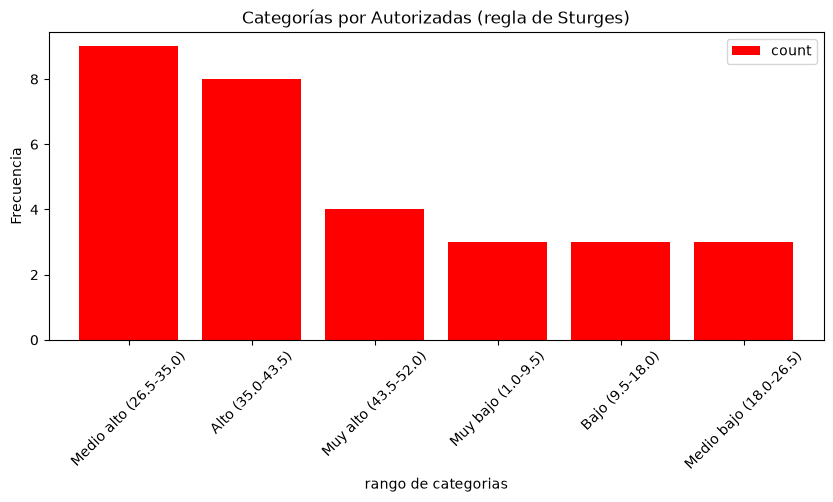

In [16]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('Categorías por Autorizadas (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

## Regla de Sturges: Formalizado

In [17]:
#Calculamos el numero total de la población "n"
Resumen['Formalizado'].info()
n = Resumen['Formalizado'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Formalizado
Non-Null Count  Dtype
--------------  -----
30 non-null     int64
dtypes: int64(1)
memory usage: 372.0 bytes


np.int64(30)

In [18]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Resumen['Formalizado'].max()
Min = Resumen['Formalizado'].min()
Limites = [Min, Max]
Limites

[np.int64(1), np.int64(25)]

In [19]:
#Calculamos el rango R
R = Max - Min
R

np.int64(24)

In [20]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [21]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(4.065011343169301)

**Creación de Categorías a partir de clases**

In [22]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([ 0.        ,  4.33333333,  8.66666667, 13.        , 17.33333333,
       21.66666667, 26.        ])

In [23]:
#Nombramos las categorías según su nivel (de mas bajo a mas alto), en vez de un numero generico,
#para que el nombre tenga sentido con lo que se esta midiendo
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (0.0-4.3)',
 'Bajo (4.3-8.7)',
 'Medio bajo (8.7-13.0)',
 'Medio alto (13.0-17.3)',
 'Alto (17.3-21.7)',
 'Muy alto (21.7-26.0)']

In [24]:
#Finalmente creamos las categorías en la columna numérica
Resumen['Formalizado'] = pd.cut(x=Resumen['Formalizado'], bins=intervalos, labels=categorias)
Resumen['Formalizado']

0         Muy bajo (0.0-4.3)
1             Bajo (4.3-8.7)
2      Medio bajo (8.7-13.0)
3         Muy bajo (0.0-4.3)
4             Bajo (4.3-8.7)
5     Medio alto (13.0-17.3)
6      Medio bajo (8.7-13.0)
7             Bajo (4.3-8.7)
8     Medio alto (13.0-17.3)
9     Medio alto (13.0-17.3)
10    Medio alto (13.0-17.3)
11          Alto (17.3-21.7)
12     Medio bajo (8.7-13.0)
13          Alto (17.3-21.7)
14    Medio alto (13.0-17.3)
15          Alto (17.3-21.7)
16      Muy alto (21.7-26.0)
17          Alto (17.3-21.7)
18     Medio bajo (8.7-13.0)
19      Muy alto (21.7-26.0)
20      Muy alto (21.7-26.0)
21      Muy alto (21.7-26.0)
22    Medio alto (13.0-17.3)
23          Alto (17.3-21.7)
24    Medio alto (13.0-17.3)
25          Alto (17.3-21.7)
26    Medio alto (13.0-17.3)
27          Alto (17.3-21.7)
28     Medio bajo (8.7-13.0)
29        Muy bajo (0.0-4.3)
Name: Formalizado, dtype: category
Categories (6, str): ['Muy bajo (0.0-4.3)' < 'Bajo (4.3-8.7)' < 'Medio bajo (8.7-13.0)' < 'Medi

In [25]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Resumen['Formalizado'].value_counts().reset_index()
Tabla_freq

,Formalizado,count
0,Medio alto (13.0-17.3),8
1,Alto (17.3-21.7),7
2,Medio bajo (8.7-13.0),5
3,Muy alto (21.7-26.0),4
4,Muy bajo (0.0-4.3),3
5,Bajo (4.3-8.7),3


In [26]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Formalizado,count
0,Medio alto (13.0-17.3),8
1,Alto (17.3-21.7),7
2,Medio bajo (8.7-13.0),5
3,Muy alto (21.7-26.0),4
4,Muy bajo (0.0-4.3),3
5,Bajo (4.3-8.7),3


In [27]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Formalizado')
Filtro_index

,count
Formalizado,
Medio alto (13.0-17.3),8
Alto (17.3-21.7),7
Medio bajo (8.7-13.0),5
Muy alto (21.7-26.0),4
Muy bajo (0.0-4.3),3
Bajo (4.3-8.7),3


Text(0, 0.5, 'Frecuencia')

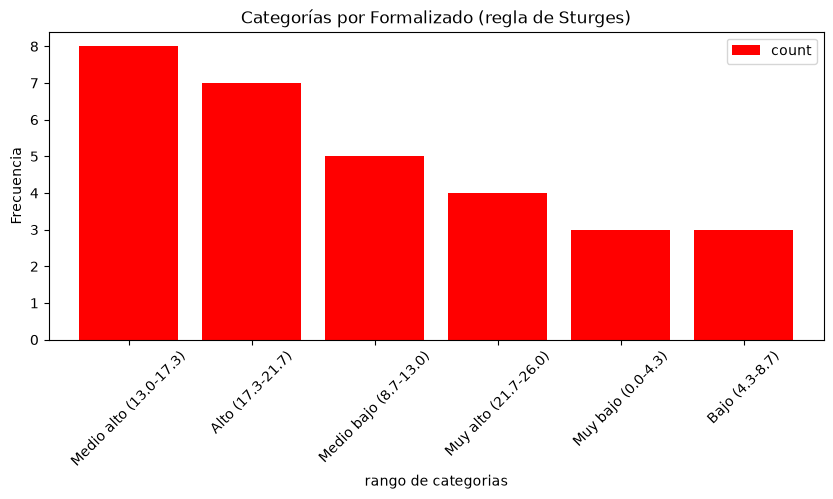

In [28]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('Categorías por Formalizado (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

## Regla de Sturges: Contado

In [29]:
#Calculamos el numero total de la población "n"
Resumen['Contado'].info()
n = Resumen['Contado'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Contado
Non-Null Count  Dtype
--------------  -----
30 non-null     int64
dtypes: int64(1)
memory usage: 372.0 bytes


np.int64(30)

In [30]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Resumen['Contado'].max()
Min = Resumen['Contado'].min()
Limites = [Min, Max]
Limites

[np.int64(0), np.int64(14)]

In [31]:
#Calculamos el rango R
R = Max - Min
R

np.int64(14)

In [32]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [33]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(2.3712566168487585)

**Creación de Categorías a partir de clases**

In [34]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([-1.        ,  1.66666667,  4.33333333,  7.        ,  9.66666667,
       12.33333333, 15.        ])

In [35]:
#Nombramos las categorías según su nivel (de mas bajo a mas alto), en vez de un numero generico,
#para que el nombre tenga sentido con lo que se esta midiendo
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (-1.0-1.7)',
 'Bajo (1.7-4.3)',
 'Medio bajo (4.3-7.0)',
 'Medio alto (7.0-9.7)',
 'Alto (9.7-12.3)',
 'Muy alto (12.3-15.0)']

In [36]:
#Finalmente creamos las categorías en la columna numérica
Resumen['Contado'] = pd.cut(x=Resumen['Contado'], bins=intervalos, labels=categorias)
Resumen['Contado']

0          Alto (9.7-12.3)
1           Bajo (1.7-4.3)
2           Bajo (1.7-4.3)
3           Bajo (1.7-4.3)
4      Muy bajo (-1.0-1.7)
5     Medio bajo (4.3-7.0)
6           Bajo (1.7-4.3)
7     Medio bajo (4.3-7.0)
8           Bajo (1.7-4.3)
9           Bajo (1.7-4.3)
10          Bajo (1.7-4.3)
11          Bajo (1.7-4.3)
12          Bajo (1.7-4.3)
13    Medio bajo (4.3-7.0)
14    Medio bajo (4.3-7.0)
15    Medio bajo (4.3-7.0)
16    Medio bajo (4.3-7.0)
17    Medio alto (7.0-9.7)
18    Medio bajo (4.3-7.0)
19    Medio alto (7.0-9.7)
20    Medio bajo (4.3-7.0)
21    Medio bajo (4.3-7.0)
22         Alto (9.7-12.3)
23    Medio bajo (4.3-7.0)
24    Medio alto (7.0-9.7)
25    Medio bajo (4.3-7.0)
26    Medio alto (7.0-9.7)
27    Medio bajo (4.3-7.0)
28    Muy alto (12.3-15.0)
29     Muy bajo (-1.0-1.7)
Name: Contado, dtype: category
Categories (6, str): ['Muy bajo (-1.0-1.7)' < 'Bajo (1.7-4.3)' < 'Medio bajo (4.3-7.0)' < 'Medio alto (7.0-9.7)' < 'Alto (9.7-12.3)' < 'Muy alto (12.3-15.0)']

In [37]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Resumen['Contado'].value_counts().reset_index()
Tabla_freq

,Contado,count
0,Medio bajo (4.3-7.0),12
1,Bajo (1.7-4.3),9
2,Medio alto (7.0-9.7),4
3,Muy bajo (-1.0-1.7),2
4,Alto (9.7-12.3),2
5,Muy alto (12.3-15.0),1


In [38]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Contado,count
0,Medio bajo (4.3-7.0),12
1,Bajo (1.7-4.3),9
2,Medio alto (7.0-9.7),4
3,Muy bajo (-1.0-1.7),2
4,Alto (9.7-12.3),2
5,Muy alto (12.3-15.0),1


In [39]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Contado')
Filtro_index

,count
Contado,
Medio bajo (4.3-7.0),12
Bajo (1.7-4.3),9
Medio alto (7.0-9.7),4
Muy bajo (-1.0-1.7),2
Alto (9.7-12.3),2
Muy alto (12.3-15.0),1


Text(0, 0.5, 'Frecuencia')

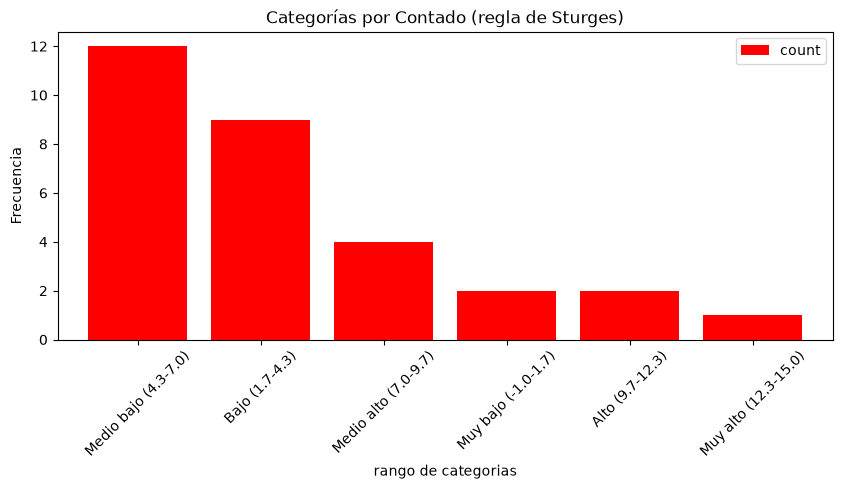

In [40]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('Categorías por Contado (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')